In [1]:
import os 
os.environ [ ' TF_CPP_MIN_LOG_LEVEL ' ] = ' 3 ' 
import sys 
import tensorflow as tf 
import textwrap 
wrapper =textwrap.TextWrapper ( width = 70 )

In [2]:
import tensorflow as tf

def display_tensor(t, name):
    # Display shape and tensor
    print(f"{name} shape: {t.shape}\n")
    print(f"{t}\n")

# Define tensors
q = tf.constant([[1.0, 0.0, 0.0], [0.0, 1.08, 0.0]])
display_tensor(q, "query")

k = tf.constant([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
display_tensor(k, "key")

v = tf.constant([[0.0, 1.0, 0.0], [1.0, 0.0, 1.0]])
display_tensor(v, "value")

m = tf.constant([[1.0, 0.0], [1.0, 1.0]])
display_tensor(m, "mask")


query shape: (2, 3)

[[1.   0.   0.  ]
 [0.   1.08 0.  ]]

key shape: (2, 3)

[[1. 2. 3.]
 [4. 5. 6.]]

value shape: (2, 3)

[[0. 1. 0.]
 [1. 0. 1.]]

mask shape: (2, 2)

[[1. 0.]
 [1. 1.]]



In [5]:
import tensorflow as tf

def dot_product_attention(q, k, v, mask=None, scale=True):
    """
    Computes dot product attention with an optional mask.
    
    Args:
        q (tf.Tensor): Query tensor of shape (..., seq_len_q, depth).
        k (tf.Tensor): Key tensor of shape (..., seq_len_k, depth).
        v (tf.Tensor): Value tensor of shape (..., seq_len_k, depth_v).
        mask (tf.Tensor, optional): A tensor that prevents attention to certain positions.
        scale (bool): Whether to scale the dot products.
    
    Returns:
        tf.Tensor: Output tensor after applying attention.
    """
    # Calculate the dot product between queries and keys
    matmul_qk = tf.matmul(q, k, transpose_b=True)

    # Scale the dot product if required
    if scale:
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        matmul_qk = matmul_qk / tf.math.sqrt(dk)

    # Apply the mask (if provided)
    if mask is not None:
        matmul_qk = matmul_qk + (1 - mask) * -1e9  # Use -1e9 for masking

    # Apply softmax to get attention weights
    attention_weights = tf.keras.activations.softmax(matmul_qk)

    # Compute the attention output
    attention_output = tf.matmul(attention_weights, v)

    return attention_output


def causal_dot_product_attention(q, k, v, scale=True):
    """
    Masked dot product self-attention.
    
    Args:
        q (tf.Tensor): Queries.
        k (tf.Tensor): Keys.
        v (tf.Tensor): Values.
        scale (bool): Whether to scale the dot products.
    
    Returns:
        tf.Tensor: Masked dot product self-attention tensor.
    """
    # Size of the penultimate dimension of the query
    mask_size = q.shape[-2]

    # Creates a lower triangular mask with ones below the diagonal
    mask = tf.experimental.numpy.tril(tf.ones((mask_size, mask_size)))

    # Perform the dot product attention
    return dot_product_attention(q, k, v, mask, scale)


def display_tensor(t, name):
    """
    Displays the shape and values of a tensor.
    
    Args:
        t (tf.Tensor): The tensor to display.
        name (str): The name of the tensor.
    """
    print(f"{name} shape: {t.shape}\n")
    print(f"{t.numpy()}\n")


# Define tensors
q = tf.constant([[1.0, 0.0, 0.0], [0.0, 1.08, 0.0]])
k = tf.constant([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
v = tf.constant([[0.0, 1.0, 0.0], [1.0, 0.0, 1.0]])

# Compute causal dot product attention
result = causal_dot_product_attention(q, k, v)

# Display the result
display_tensor(result, "result")

result shape: (2, 3)

[[0.        1.        0.       ]
 [0.8665294 0.1334706 0.8665294]]



In [10]:
import tensorflow as tf

def create_padding_mask(decoder_token_ids):
    """
    Creates a binary mask for padding cells in the input tensor.
    
    Args:
        decoder_token_ids (tf.Tensor): Tensor of shape (n, m).
    
    Returns:
        tf.Tensor: Binary mask tensor of shape (n, 1, m).
    """
    # Create a binary mask where 1 represents padding (value 0) and 0 otherwise
    mask = tf.cast(tf.math.equal(decoder_token_ids, 0), tf.float32)
    return mask[:, tf.newaxis, :]

# Define the input tensor
x = tf.constant([[7., 6., 0., 0., 0.],
                 [1., 2., 3., 0., 0.],
                 [3., 0., 0., 0., 0.]])

# Create the mask for x
mask = create_padding_mask(x)

# Extend the dimension of x to match the mask
x_extended = x[:, tf.newaxis, :]

print("Softmax of non-masked vectors:\n")
print(tf.keras.activations.softmax(x_extended))

# Apply masking by adding (1 - mask) * -1e9 to x_extended
masked_x = x_extended + (1 - mask) * -1e9

print("\nSoftmax of masked vectors:\n")
print(tf.keras.activations.softmax(masked_x))


Softmax of non-masked vectors:

tf.Tensor(
[[[7.2959948e-01 2.6840466e-01 6.6530862e-04 6.6530862e-04 6.6530862e-04]]

 [[8.4437370e-02 2.2952457e-01 6.2391245e-01 3.1062772e-02 3.1062772e-02]]

 [[8.3392531e-01 4.1518699e-02 4.1518696e-02 4.1518696e-02 4.1518696e-02]]], shape=(3, 1, 5), dtype=float32)

Softmax of masked vectors:

tf.Tensor(
[[[0.         0.         0.33333334 0.33333334 0.33333334]]

 [[0.         0.         0.         0.5        0.5       ]]

 [[0.         0.25       0.25       0.25       0.25      ]]], shape=(3, 1, 5), dtype=float32)


In [17]:
def create_look_ahead_mask(sequence_length):
    mask=tf.linalg.band_part(tf.ones((1,sequence_length,sequence_length)),-1,0)
    return mask

In [18]:
x=tf.random.uniform((1,3))
temp=create_look_ahead_mask(x.shape[1])
temp

<tf.Tensor: shape=(1, 3, 3), dtype=float32, numpy=
array([[[1., 0., 0.],
        [1., 1., 0.],
        [1., 1., 1.]]], dtype=float32)>

In [19]:
# def get_angles(position,k,d_model):
#     i=k//2
#     angle_rates=1/np.power(10000,(2*i)/np.float32(d_model))
#     return position*angle_rates

In [20]:
import numpy as np
import tensorflow as tf

def get_angles(position, k, d_model):
    """
    Computes the angle values for the positional encoding.
    
    Args:
        position (np.ndarray): Positions to be encoded.
        k (np.ndarray): Index for encoding.
        d_model (int): Encoding size (model dimensionality).
    
    Returns:
        np.ndarray: Angle rates used for positional encoding.
    """
    i = k // 2
    angle_rates = 1 / np.power(10000, (2 * i) / np.float32(d_model))
    return position * angle_rates

def positional_encoding(positions, d_model):
    """
    Precomputes a matrix with all the positional encodings.
    
    Args:
        positions (int): Maximum number of positions to be encoded.
        d_model (int): Encoding size.
    
    Returns:
        tf.Tensor: A matrix of shape (1, positions, d_model) containing the positional encodings.
    """
    # Compute the angles for positional encoding
    angle_rads = get_angles(np.arange(positions)[:, np.newaxis], 
                            np.arange(d_model)[np.newaxis, :], 
                            d_model)
    
    # Apply sin to even indices (0, 2, 4, ...)
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    
    # Apply cos to odd indices (1, 3, 5, ...)
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    
    # Add an extra dimension to make the positional encoding shape (1, positions, d_model)
    pos_encoding = angle_rads[np.newaxis, ...]

    return tf.cast(pos_encoding, dtype=tf.float32)

# Example usage
positions = 50  # Maximum positions to encode
d_model = 512   # Model dimensionality
pos_encoding = positional_encoding(positions, d_model)
print(pos_encoding)


tf.Tensor(
[[[ 0.00000000e+00  1.00000000e+00  0.00000000e+00 ...  1.00000000e+00
    0.00000000e+00  1.00000000e+00]
  [ 8.41470957e-01  5.40302277e-01  8.21856201e-01 ...  1.00000000e+00
    1.03663289e-04  1.00000000e+00]
  [ 9.09297407e-01 -4.16146845e-01  9.36414719e-01 ...  1.00000000e+00
    2.07326579e-04  1.00000000e+00]
  ...
  [ 1.23573124e-01 -9.92335498e-01  9.77189839e-01 ...  9.99987245e-01
    4.87215538e-03  9.99988139e-01]
  [-7.68254638e-01 -6.40144348e-01  7.31235921e-01 ...  9.99986708e-01
    4.97581763e-03  9.99987602e-01]
  [-9.53752637e-01  3.00592542e-01 -1.44026920e-01 ...  9.99986112e-01
    5.07947942e-03  9.99987125e-01]]], shape=(1, 50, 512), dtype=float32)


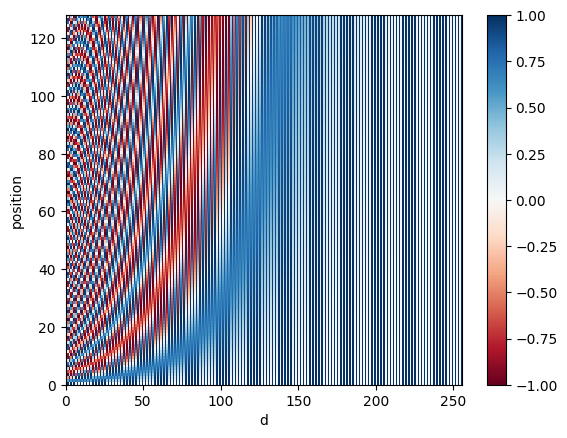

In [29]:
import matplotlib.pyplot as plt
pos_encoding=positional_encoding(128,256)
plt.pcolormesh(pos_encoding[0],cmap='RdBu')#RdBu, tab20,'coolwarm'=Blue to red,'viridis'= Shades of green to yellow,
plt.xlabel('d')
plt.xlim(0,256)
plt.ylabel('position')
plt.colorbar()
plt.show()
